# Multi-Run BO vs. Random Search Analysis

This notebook compares the combined outputs produced by `multi_run_bo.py` and `multi_run_random_search.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

RESULTS_DIR = Path("multi_run_results_changed_weights")
TRIAL_FILES = {
    "bo": RESULTS_DIR / "bo_all_trials.csv",
    "random_search": RESULTS_DIR / "random_search_all_trials.csv",
}
SUMMARY_FILE = RESULTS_DIR / "summary.csv"
BEST_PARAMETERS_FILE = RESULTS_DIR / "best_parameters_summary.csv"

PARAMETER_COLUMNS = [
    "preparation_capacity",
    "sorting_capacity",
    "analysis1_capacity",
    "analysis2_capacity",
    "evaluation_capacity",
    "dispatching_capacity",
    "worker_capacity",
]

PARAMETER_LABELS = [column.replace("_capacity", "").replace("analysis", "analysis ") for column in PARAMETER_COLUMNS]
METHOD_COLORS = {
    "BO": "tab:blue",
    "Random Search": "tab:orange",
}


In [2]:
def load_trials() -> pd.DataFrame:
    existing = {method: path for method, path in TRIAL_FILES.items() if path.exists()}
    missing = {method: path for method, path in TRIAL_FILES.items() if not path.exists()}

    if not existing:
        missing_text = "\n".join(f"- {path}" for path in missing.values())
        raise FileNotFoundError(
            "No combined trial CSVs found. Run these first from the BO folder:\n"
            "  python multi_run_bo.py\n"
            "  python multi_run_random_search.py\n\n"
            f"Missing files:\n{missing_text}"
        )

    if missing:
        print("Partial results loaded. Missing files:")
        for path in missing.values():
            print(f"- {path}")

    frames = []
    for method, path in existing.items():
        df = pd.read_csv(path)
        if "method" not in df.columns:
            df["method"] = method
        frames.append(df)

    trials = pd.concat(frames, ignore_index=True, sort=False)
    required = {"method", "run_index", "trial_index", "objective_mean", "best_objective_so_far"}
    missing_columns = sorted(required - set(trials.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns in trial results: {missing_columns}")

    trials["method"] = trials["method"].replace({"bo": "BO", "random_search": "Random Search"})
    return trials.sort_values(["method", "run_index", "trial_index"]).reset_index(drop=True)


trials = load_trials()
display(trials.head())
print(f"Loaded {len(trials)} trial rows from {trials['run_index'].nunique()} run indices.")

,method,run_index,trial_index,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,...,worker_capacity_norm_mean,time_in_system_mean_norm_mean,time_in_system_std_norm_mean,objective_completed_contribution_mean,objective_late_contribution_mean,objective_station_capacity_contribution_mean,objective_worker_capacity_contribution_mean,objective_time_mean_contribution_mean,objective_time_std_contribution_mean,best_objective_so_far
0,BO,0,0,3,2,4,1,1,1,5,...,0.444444,0.766155,0.411921,-0.219228,0.465168,0.750,0.444444,0.306462,0.0,1.746847
1,BO,0,1,4,4,2,3,5,4,9,...,0.888889,0.563673,0.297780,-0.254273,0.293372,2.000,0.888889,0.225469,0.0,1.746847
2,BO,0,2,3,3,4,3,3,5,1,...,0.000000,1.402402,0.768668,-0.089150,0.731633,1.875,0.000000,0.560961,0.0,1.746847
3,BO,0,3,1,3,1,5,3,3,6,...,0.555556,1.295841,0.719023,-0.129018,0.687958,1.250,0.555556,0.518336,0.0,1.746847
4,BO,0,4,1,2,2,5,2,1,2,...,0.111111,0.824883,0.446517,-0.166550,0.580806,0.875,0.111111,0.329953,0.0,1.730320


Loaded 1200 trial rows from 20 run indices.


## Best Objective So Far Per Run

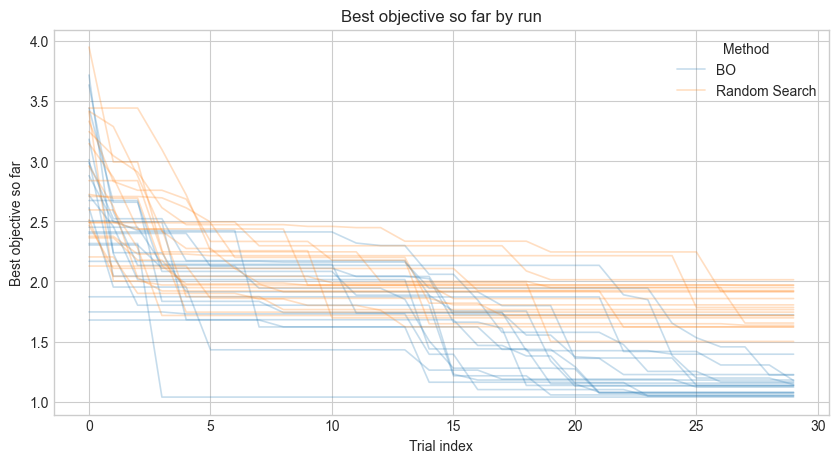

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

labeled_methods = set()
for (method, run_index), run_df in trials.groupby(["method", "run_index"], sort=False):
    label = method if method not in labeled_methods else "_nolegend_"
    labeled_methods.add(method)
    ax.plot(
        run_df["trial_index"],
        run_df["best_objective_so_far"],
        color=METHOD_COLORS.get(method),
        alpha=0.25,
        linewidth=1.2,
        label=label,
    )

ax.legend(title="Method")
ax.set_title("Best objective so far by run")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
plt.show()


## Median With IQR Band

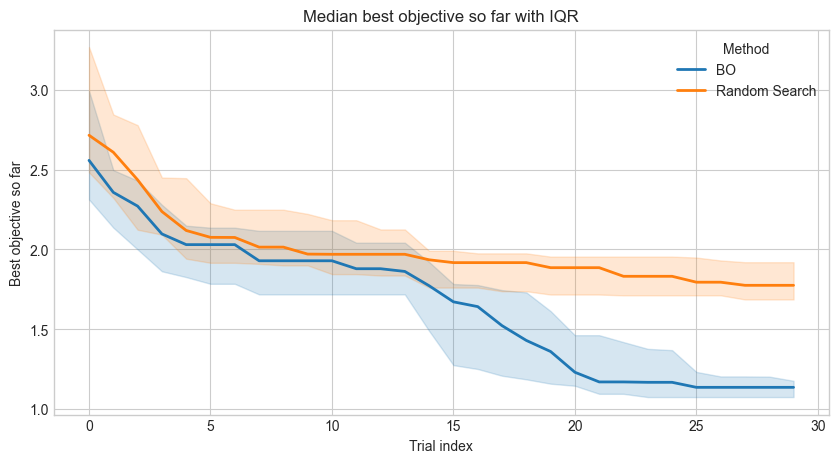

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

for method, method_df in trials.groupby("method", sort=False):
    grouped = method_df.groupby("trial_index")["best_objective_so_far"]
    stats = grouped.quantile([0.25, 0.5, 0.75]).unstack()
    stats.columns = ["q25", "median", "q75"]
    color = METHOD_COLORS.get(method)
    ax.plot(stats.index, stats["median"], linewidth=2.0, color=color, label=method)
    ax.fill_between(stats.index, stats["q25"], stats["q75"], color=color, alpha=0.18)

ax.legend(title="Method")
ax.set_title("Median best objective so far with IQR")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
plt.show()


## Final Best Objective Per Run

C:\Users\fabia\AppData\Local\Temp\ipykernel_49664\711475105.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)


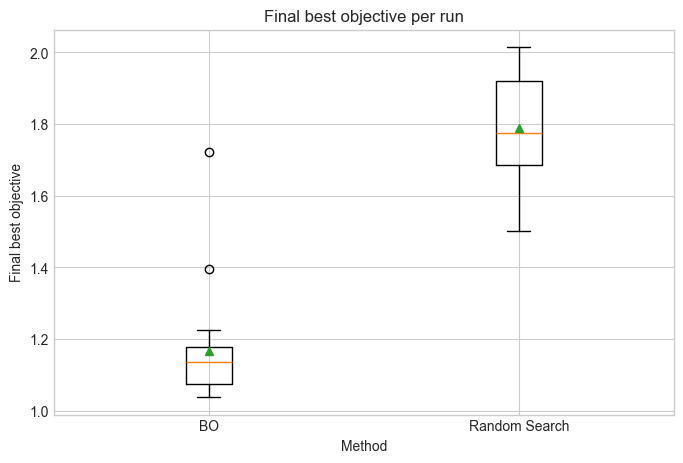

,method,run_index,final_best_objective
29,BO,0,1.047495
59,BO,1,1.395194
89,BO,2,1.078600
119,BO,3,1.135490
149,BO,4,1.221685
179,BO,5,1.070999
209,BO,6,1.076101
239,BO,7,1.225840
269,BO,8,1.175813
299,BO,9,1.142139


In [5]:
final_trials = (
    trials.sort_values(["method", "run_index", "trial_index"])
    .groupby(["method", "run_index"], as_index=False)
    .tail(1)
    .copy()
)
final_trials["final_best_objective"] = final_trials["best_objective_so_far"]

methods = list(final_trials["method"].drop_duplicates())
data = [
    final_trials.loc[final_trials["method"] == method, "final_best_objective"].dropna()
    for method in methods
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=methods, showmeans=True)
ax.set_title("Final best objective per run")
ax.set_xlabel("Method")
ax.set_ylabel("Final best objective")
plt.show()

display(final_trials[["method", "run_index", "final_best_objective"]].sort_values(["method", "run_index"]))

## Best Parameter Settings

Best parameter setting found across all runs per method:


,method,run_index,trial_index,objective_mean,objective_std,n_valid_replications,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,total_capacity
513,BO,17,3,1.038394,0.065658,30,1,2,2,1,1,1,3,11
1099,Random Search,16,19,1.501321,0.053914,30,2,1,1,1,1,2,2,10


Best parameter setting per run written to multi_run_results_changed_weights\best_parameters_summary.csv


,method,run_index,trial_index,objective_mean,objective_std,n_valid_replications,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,total_capacity
0,BO,0,23,1.047495,0.073441,30,1,2,2,1,1,1,3,11
1,BO,1,24,1.395194,0.070387,30,1,4,3,1,1,2,4,16
2,BO,2,21,1.078600,0.125861,30,1,3,3,1,1,1,3,13
3,BO,3,18,1.135490,0.141572,30,1,1,1,1,1,1,1,7
4,BO,4,28,1.221685,0.228423,30,2,3,3,1,3,1,4,17
5,BO,5,21,1.070999,0.123025,30,1,3,3,1,1,1,3,13
6,BO,6,21,1.076101,0.084711,30,1,3,3,1,1,1,3,13
7,BO,7,22,1.225840,0.311604,30,2,3,3,1,2,1,4,16
8,BO,8,29,1.175813,0.057012,30,1,2,2,1,2,1,3,12
9,BO,9,29,1.142139,0.135456,30,1,1,1,1,1,1,1,7


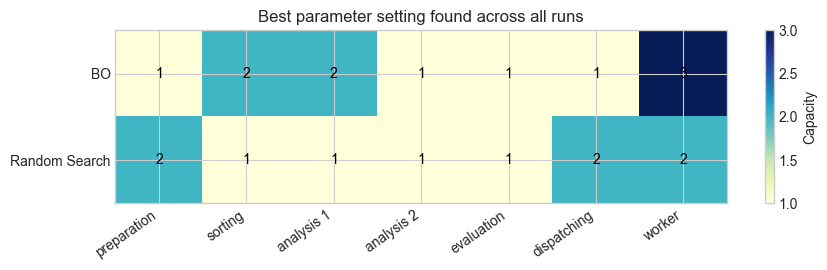

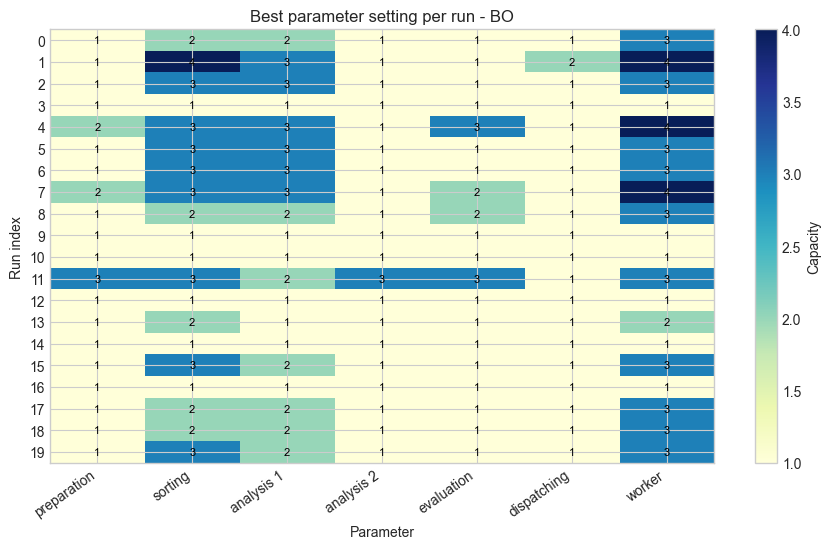

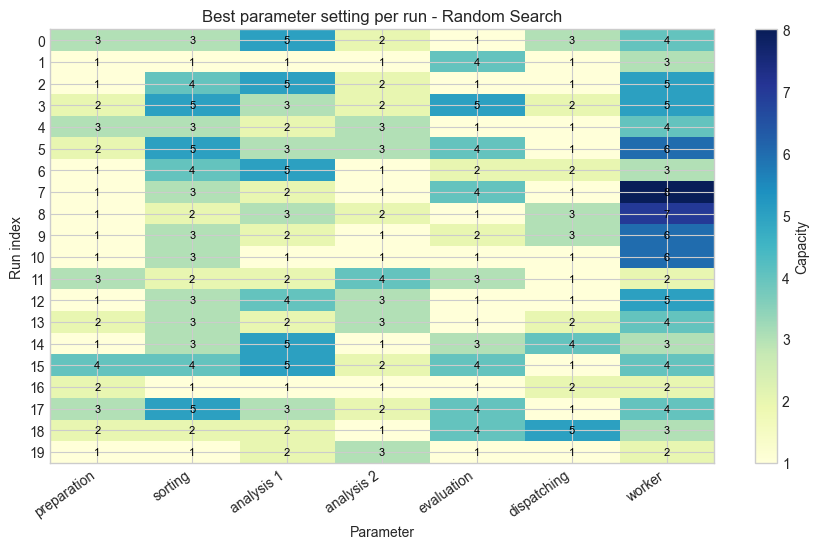

In [6]:
missing_parameters = [column for column in PARAMETER_COLUMNS if column not in trials.columns]
if missing_parameters:
    raise ValueError(f"Missing parameter columns in trial results: {missing_parameters}")

best_parameter_rows = []
for method, method_df in trials.groupby("method", sort=False):
    best_row = method_df.loc[method_df["objective_mean"].idxmin()].copy()
    best_parameter_rows.append(best_row)

best_parameters = pd.DataFrame(best_parameter_rows)
best_parameters["total_capacity"] = best_parameters[PARAMETER_COLUMNS].sum(axis=1)
best_parameter_columns = [
    "method",
    "run_index",
    "trial_index",
    "objective_mean",
    "objective_std",
    "n_valid_replications",
    *PARAMETER_COLUMNS,
    "total_capacity",
]
best_parameters = best_parameters[best_parameter_columns].sort_values("objective_mean")

print("Best parameter setting found across all runs per method:")
display(best_parameters)

best_parameters_by_run = (
    trials.loc[trials.groupby(["method", "run_index"])["objective_mean"].idxmin(), best_parameter_columns[:-1]]
    .sort_values(["method", "run_index"])
    .reset_index(drop=True)
)
best_parameters_by_run["total_capacity"] = best_parameters_by_run[PARAMETER_COLUMNS].sum(axis=1)
try:
    best_parameters_by_run.to_csv(BEST_PARAMETERS_FILE, index=False)
except PermissionError as error:
    print(f"Could not write {BEST_PARAMETERS_FILE}: {error}")
else:
    print(f"Best parameter setting per run written to {BEST_PARAMETERS_FILE}")

display(best_parameters_by_run)

global_heatmap = best_parameters.set_index("method")[PARAMETER_COLUMNS]
fig, ax = plt.subplots(figsize=(9, 2.8))
image = ax.imshow(global_heatmap.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set_title("Best parameter setting found across all runs")
ax.set_xticks(np.arange(len(PARAMETER_COLUMNS)), labels=PARAMETER_LABELS, rotation=35, ha="right")
ax.set_yticks(np.arange(len(global_heatmap.index)), labels=global_heatmap.index)
for row_idx in range(global_heatmap.shape[0]):
    for col_idx in range(global_heatmap.shape[1]):
        ax.text(col_idx, row_idx, int(global_heatmap.iloc[row_idx, col_idx]), ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, label="Capacity")
plt.tight_layout()
plt.show()

for method, method_df in best_parameters_by_run.groupby("method", sort=False):
    heatmap_data = method_df.set_index("run_index")[PARAMETER_COLUMNS]
    fig_height = max(4, 0.28 * len(heatmap_data))
    fig, ax = plt.subplots(figsize=(9, fig_height))
    image = ax.imshow(heatmap_data.to_numpy(), aspect="auto", cmap="YlGnBu")
    ax.set_title(f"Best parameter setting per run - {method}")
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Run index")
    ax.set_xticks(np.arange(len(PARAMETER_COLUMNS)), labels=PARAMETER_LABELS, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(heatmap_data.index)), labels=heatmap_data.index)
    for row_idx in range(heatmap_data.shape[0]):
        for col_idx in range(heatmap_data.shape[1]):
            ax.text(col_idx, row_idx, int(heatmap_data.iloc[row_idx, col_idx]), ha="center", va="center", fontsize=8, color="black")
    fig.colorbar(image, ax=ax, label="Capacity")
    plt.tight_layout()
    plt.show()


## Optional Final KPI Comparison

method,BO,Random Search
n_orders_completed_mean,318.583333,347.083333
n_orders_late_mean,144.166667,195.833333
n_orders_incomplete_mean,682.833333,649.483333
late_total_norm_mean,0.884399,0.868058
time_in_system_mean_mean,281.207457,320.841856
wip_time_in_system_mean_mean,493.205793,465.866005


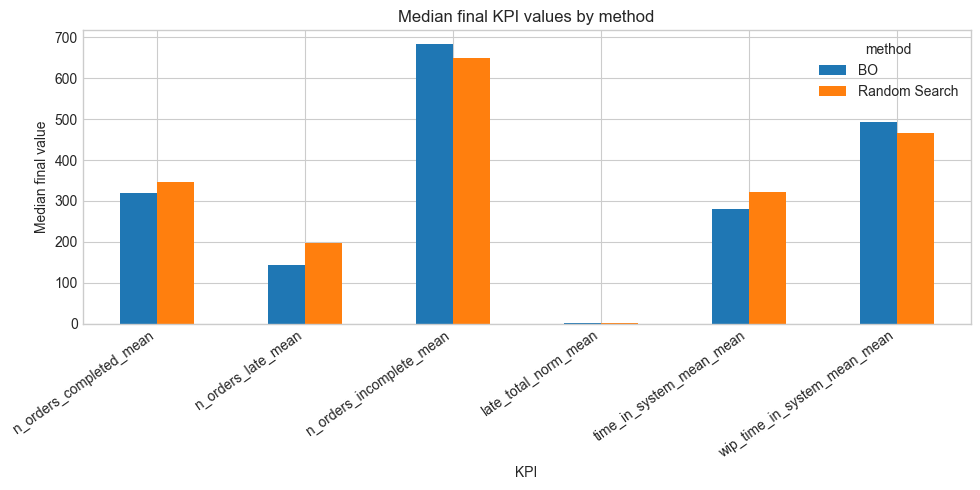

In [7]:
candidate_kpis = [
    "n_orders_completed_mean",
    "n_orders_late_mean",
    "n_orders_incomplete_mean",
    "late_total_norm_mean",
    "time_in_system_mean_mean",
    "wip_time_in_system_mean_mean",
]
available_kpis = [column for column in candidate_kpis if column in final_trials.columns]

if not available_kpis:
    print("No optional final KPI columns found in the combined trial results.")
else:
    kpi_summary = final_trials.groupby("method")[available_kpis].median().T
    display(kpi_summary)
    ax = kpi_summary.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Median final KPI values by method")
    ax.set_xlabel("KPI")
    ax.set_ylabel("Median final value")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()